# Project Cycle 3 - Week A Draft Notebook

## Research Question

**Is the proportion of current cigarette use different between male and female students?**

This project compares current cigarette use between male and female students using the YRBS_2007 dataset.


## Variables

**Group Variable:**
- `WhatIsYourSex`

**Response Variable:**
- `CurrentCigaretteUse`

The response variable is binary after recoding:
- `1` = current cigarette use
- `0` = no current cigarette use


## Method Selection

Because the response variable is binary and the goal is to compare proportions between two independent groups, this project will use a **two-proportion z-test** in the next stage.

A two-sample t-test is not appropriate here because the response variable is categorical, not quantitative.


In [19]:
# Import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [20]:
# Load the dataset
possible_paths = [
    Path("YRBS_2007.csv"),
    Path("data/raw/YRBS_2007.csv"),
    Path("../data/raw/YRBS_2007.csv")
]

data_path = None
for path in possible_paths:
    if path.exists():
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError("Cannot find YRBS_2007.csv. Please check the file location.")

df = pd.read_csv(data_path)
print("Loaded file from:", data_path)

# Preview the first few rows
df.head()


Loaded file from: ..\data\raw\YRBS_2007.csv


,RaceEth,HowOldAreYou,WhatIsYourSex,InWhatGradeAreYou,AreYouHispanicOrLatino,WhatIsYourRace,HowTallAreYouWithoutShoesInMeters,HowMuchDoYouWeighWithoutShoesInKG,BicyleHelmetUse,SeatBeltUse,...,InjuredWhileExercising,HIVTesting,SunscreenUse,SunProtection,Sleep,HealthInGeneral,BMIPCT,weight,stratum,psu
0,7.0,4.0,2.0,2.0,1.0,C,NaN,NaN,2.0,1.0,...,3.0,2.0,1.0,1.0,5.0,3.0,NaN,1.5104,101,11030
1,5.0,7.0,2.0,2.0,2.0,E,1.70,68.04,4.0,4.0,...,2.0,3.0,1.0,5.0,4.0,3.0,66.531824,1.8559,101,11030
2,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,5.0,3.0,...,2.0,3.0,2.0,1.0,1.0,1.0,NaN,1.8559,101,11030
3,7.0,1.0,1.0,1.0,1.0,A,1.63,79.38,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,98.174319,1.3264,101,11030
4,7.0,1.0,1.0,5.0,1.0,B,NaN,NaN,6.0,5.0,...,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.3264,101,11030


## 2. Select Required Variables

Only the group variable and response variable are needed for Week A.


In [21]:
# Select variables
df_selected = df[["WhatIsYourSex", "CurrentCigaretteUse"]].copy()

# Check missing values
df_selected.isna().sum()


WhatIsYourSex           13
CurrentCigaretteUse    718
dtype: int64

## 3. Clean Missing Values

Rows with missing values in the selected variables are removed.


In [22]:
# Remove missing values
df_clean = df_selected.dropna().copy()

# Check dataset size after cleaning
df_clean.shape


(13312, 2)

## 4. Recode Variables

### Gender
- `1` = Male
- `2` = Female

### Current Cigarette Use
- Original code `1` = no current cigarette use → recoded as `0`
- Original codes `2–7` = current cigarette use → recoded as `1`


In [23]:
# Recode gender
df_clean["gender"] = df_clean["WhatIsYourSex"].map({
    1: "Male",
    2: "Female"
})

# Recode current cigarette use
df_clean["smoke_now"] = np.where(
    df_clean["CurrentCigaretteUse"] == 1,
    0,
    1
)

# Remove rows with invalid gender values if any
df_clean = df_clean.dropna(subset=["gender"])

# Preview recoded data
df_clean.head()


,WhatIsYourSex,CurrentCigaretteUse,gender,smoke_now
0,2.0,7.0,Female,1
3,1.0,1.0,Male,0
4,1.0,1.0,Male,0
5,1.0,1.0,Male,0
6,1.0,1.0,Male,0


## 5. Descriptive Statistics

Before conducting inference, we first summarize the sample size and current cigarette use proportion in each gender group.


In [24]:
# Sample size by gender
sample_size = df_clean.groupby("gender").size().reset_index(name="n")
sample_size


,gender,n
0,Female,6572
1,Male,6740


In [25]:
# Summary table
summary_table = df_clean.groupby("gender").agg(
    n=("smoke_now", "size"),
    current_smokers=("smoke_now", "sum"),
    proportion_current_smoking=("smoke_now", "mean")
).reset_index()

summary_table


,gender,n,current_smokers,proportion_current_smoking
0,Female,6572,1418,0.215764
1,Male,6740,1167,0.173145


## 6. Visualization

This bar chart compares the proportion of current cigarette use between male and female students.


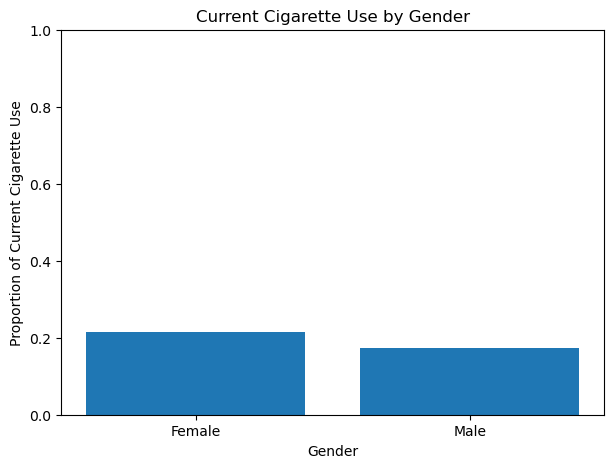

In [26]:
# Bar chart of current cigarette use proportion by gender
plt.figure(figsize=(7, 5))
plt.bar(summary_table["gender"], summary_table["proportion_current_smoking"])
plt.xlabel("Gender")
plt.ylabel("Proportion of Current Cigarette Use")
plt.title("Current Cigarette Use by Gender")
plt.ylim(0, 1)
plt.show()


## 7. Save Cleaned Data and Summary Table

The cleaned dataset and summary table can be saved for later use in Week B.


In [27]:
# Save cleaned data and summary table

# Save according to notebook location
if Path("../data").exists() and Path("../outputs").exists():
    df_clean.to_csv("../data/processed/cycle3_cleaned_weekA.csv", index=False)
    summary_table.to_csv("../outputs/tables/weekA_summary_table.csv", index=False)
else:
    df_clean.to_csv("data/processed/cycle3_cleaned_weekA.csv", index=False)
    summary_table.to_csv("outputs/tables/weekA_summary_table.csv", index=False)

print("Files saved successfully.")


Files saved successfully.


## 8. Initial Interpretation

The descriptive statistics show the proportion of current cigarette use for male and female students.

At this stage, the analysis only describes the difference between the two groups. In Week B, a formal two-proportion z-test will be used to determine whether the difference is statistically significant.


# Hypotheses

Null Hypothesis (H0):
The proportion of current cigarette use is the same for male and female students.

Alternative Hypothesis (H1):
The proportion of current cigarette use is different for male and female students.

In [28]:
# Group counts

male = df_clean[df_clean["gender"] == "Male"]
female = df_clean[df_clean["gender"] == "Female"]

male_smokers = male["smoke_now"].sum()
female_smokers = female["smoke_now"].sum()

male_n = len(male)
female_n = len(female)

print("Male smokers:", male_smokers)
print("Male sample size:", male_n)

print("Female smokers:", female_smokers)
print("Female sample size:", female_n)

Male smokers: 1167
Male sample size: 6740
Female smokers: 1418
Female sample size: 6572


In [29]:
from statsmodels.stats.proportion import proportions_ztest

# Success counts
count = [male_smokers, female_smokers]

# Sample sizes
nobs = [male_n, female_n]

# Two-proportion z-test
z_stat, p_value = proportions_ztest(count, nobs)

print("Z-statistic:", z_stat)
print("P-value:", p_value)

Z-statistic: -6.214820309970149
P-value: 5.138341623910967e-10


In [30]:
# 95% Confidence Interval for the difference in proportions

# Difference = Male proportion - Female proportion
male_prop = male_smokers / male_n
female_prop = female_smokers / female_n
difference = male_prop - female_prop

# Standard error for difference in proportions
se_diff = np.sqrt((male_prop * (1 - male_prop) / male_n) + (female_prop * (1 - female_prop) / female_n))

# 95% z critical value
z_critical = 1.96

ci_low = difference - z_critical * se_diff
ci_high = difference + z_critical * se_diff

print("95% Confidence Interval for the Difference in Proportions:")
print("Lower bound:", ci_low)
print("Upper bound:", ci_high)


95% Confidence Interval for the Difference in Proportions:
Lower bound: -0.05605386170062185
Upper bound: -0.029183030356500297


In [31]:
male_prop = male_smokers / male_n
female_prop = female_smokers / female_n

difference = male_prop - female_prop

print("Male proportion:", male_prop)
print("Female proportion:", female_prop)
print("Difference in proportions:", difference)

Male proportion: 0.1731454005934718
Female proportion: 0.21576384662203288
Difference in proportions: -0.042618446028561074


In [32]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis.")
else:
    print("Fail to reject the null hypothesis.")

Reject the null hypothesis.


# Interpretation

The analysis compares the proportion of current cigarette use between male and female students.

The two-proportion z-test provides evidence about whether the observed difference between the two groups is statistically significant.

The confidence interval estimates the plausible range for the true difference in cigarette use proportions between male and female students.

Why use two-proportion z-test?

Because the response variable is binary,
and we are comparing proportions between two independent groups.
What does the p-value mean?
The p-value measures the evidence against the null hypothesis.
A small p-value suggests the group proportions are significantly different.
What does the confidence interval mean?
The confidence interval gives a plausible range for the true difference in cigarette use proportions between male and female students.

# Week C: Integration and Presentation

This section completes the final interpretation, uncertainty analysis, assumptions, limitations, and presentation preparation.

## Assumptions

1. **Independent groups:** Male and female students are treated as separate groups. Each student belongs to only one group.

2. **Binary response variable:** Current cigarette use is recoded as 1 for current use and 0 for no current use.

3. **Large sample size:** The sample sizes in both groups should be large enough for a two-proportion z-test.

4. **Observational data:** This dataset comes from a survey, so the result can show association, but it cannot prove causation.

In [33]:
# Create a final result table for Week C

final_results = pd.DataFrame({
    "Statistic": [
        "Male sample size",
        "Female sample size",
        "Male current smokers",
        "Female current smokers",
        "Male smoking proportion",
        "Female smoking proportion",
        "Difference in proportions (Male - Female)",
        "Z-statistic",
        "P-value",
        "95% CI lower bound",
        "95% CI upper bound"
    ],
    "Value": [
        male_n,
        female_n,
        male_smokers,
        female_smokers,
        round(male_prop, 4),
        round(female_prop, 4),
        round(difference, 4),
        round(z_stat, 4),
        round(p_value, 4),
        round(ci_low, 4),
        round(ci_high, 4)
    ]
})

final_results

,Statistic,Value
0,Male sample size,6740.0000
1,Female sample size,6572.0000
2,Male current smokers,1167.0000
3,Female current smokers,1418.0000
4,Male smoking proportion,0.1731
5,Female smoking proportion,0.2158
6,Difference in proportions (Male - Female),-0.0426
7,Z-statistic,-6.2148
8,P-value,0.0000
9,95% CI lower bound,-0.0561


In [34]:
# Save final result table


if Path("../outputs").exists():
    final_results.to_csv("../outputs/tables/weekC_final_results.csv", index=False)
else:
    final_results.to_csv("outputs/tables/weekC_final_results.csv", index=False)

print("Final results table saved successfully.")

Final results table saved successfully.


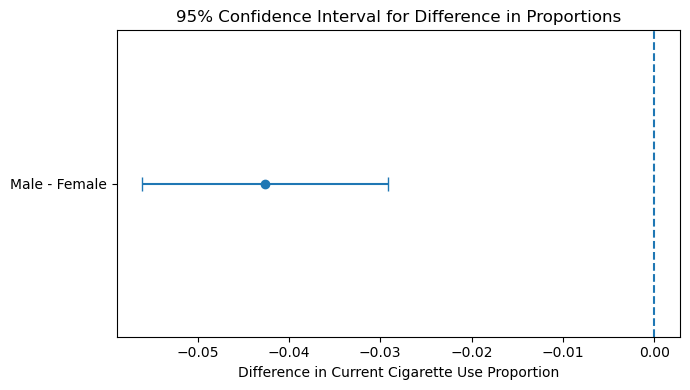

In [35]:
# Confidence interval plot for the difference in proportions

plt.figure(figsize=(7, 4))
plt.errorbar(
    x=[difference],
    y=[0],
    xerr=[[difference - ci_low], [ci_high - difference]],
    fmt='o',
    capsize=5
)
plt.axvline(0, linestyle='--')
plt.yticks([0], ["Male - Female"])
plt.xlabel("Difference in Current Cigarette Use Proportion")
plt.title("95% Confidence Interval for Difference in Proportions")
plt.tight_layout()


if Path("../outputs").exists():
    plt.savefig("../outputs/figures/weekC_confidence_interval_plot.png", dpi=300, bbox_inches="tight")
else:
    plt.savefig("outputs/figures/weekC_confidence_interval_plot.png", dpi=300, bbox_inches="tight")

plt.show()

## Uncertainty Analysis

The confidence interval gives a range of possible values for the true difference in current cigarette use proportions between male and female students.

If the confidence interval does not include 0, it suggests that the difference between the two groups is statistically meaningful at the 0.05 level.

If the confidence interval includes 0, it suggests that the observed difference may be due to sampling variation.

## Limitations

1. The data are based on self-reported survey answers.

2. Some students may not answer honestly or accurately.

3. This analysis only compares gender and current cigarette use. Other factors are not included.

4. The result shows association, not causation.

## Final Conclusion Template

Use the correct sentence based on your p-value.

### If p-value < 0.05

At the 0.05 significance level, there is enough evidence to conclude that the proportion of current cigarette use is different between male and female students. The estimated difference in proportions shows which group has a higher current smoking proportion.

### If p-value ≥ 0.05

At the 0.05 significance level, there is not enough evidence to conclude that the proportion of current cigarette use is different between male and female students. The observed difference may be due to sampling variation.

In [36]:
# Automatically generate a final conclusion based on the p-value

if p_value < 0.05:
    decision = "reject the null hypothesis"
    significance = "there is enough evidence that the smoking proportions are different between male and female students"
else:
    decision = "fail to reject the null hypothesis"
    significance = "there is not enough evidence that the smoking proportions are different between male and female students"

if difference > 0:
    direction = "Male students have a higher current cigarette use proportion than female students in this sample."
elif difference < 0:
    direction = "Female students have a higher current cigarette use proportion than male students in this sample."
else:
    direction = "Male and female students have the same current cigarette use proportion in this sample."

final_conclusion = f"""
At the 0.05 significance level, we {decision}.
This means that {significance}.
{direction}
The estimated difference in proportions is {difference:.4f}, with a 95% confidence interval from {ci_low:.4f} to {ci_high:.4f}.
Because this is observational survey data, the result shows association, not causation.
"""

print(final_conclusion)


At the 0.05 significance level, we reject the null hypothesis.
This means that there is enough evidence that the smoking proportions are different between male and female students.
Female students have a higher current cigarette use proportion than male students in this sample.
The estimated difference in proportions is -0.0426, with a 95% confidence interval from -0.0561 to -0.0292.
Because this is observational survey data, the result shows association, not causation.



## One-Slide Infographic Content

**Title:** Gender and Current Cigarette Use

**Research Question:** Is the proportion of current cigarette use different between male and female students?

**Group Variable:** WhatIsYourSex

**Response Variable:** CurrentCigaretteUse

**Method:** Two-Proportion Z-Test

**Key Results to Put on Slide:**
- Male proportion
- Female proportion
- Difference in proportions
- p-value
- 95% confidence interval

**Suggested Figure:** Bar chart of current cigarette use by gender.

**Conclusion:** Use the final conclusion generated above.

## Short Presentation Script

Our research question is whether the proportion of current cigarette use is different between male and female students.

The group variable is sex, and the response variable is current cigarette use. We recoded current cigarette use into a binary variable: 1 means current cigarette use, and 0 means no current cigarette use.

Because the response variable is binary and we compare two groups, we used a two-proportion z-test.

We first compared the smoking proportions using descriptive statistics and a bar chart. Then we used a hypothesis test and a confidence interval to evaluate the difference.

Our final result should be interpreted as an association, not causation, because the data come from an observational survey.